# Lab - Zero-Shot Learning Part 1 - CLIP

## E6692 Spring 2026


### <font color="red"><strong>[NOTE]</strong></font> This part of the lab is separate from the Parallel Computing partion of the lab, and can be completed independently of the rest of the lab.

## Introduction

### Zero-shot learning
In previous labs (lab 3), we have trained image classifiers on specific tasks using a fix set of classes that we defined and collected data for. However, in recent years, deep learning has advanced to the point where pre-trained models can be applied to new tasks without having to perform any additional training. This kind of problem setup is called "zero-shot learning", where in test / inference time, a model can predict classes not seen during training. These models are typically trained on a large set of image-text pairs, and learns to associate observed text-classes present in the given images. One such model is "CLIP", which has shown remarkable test performance on image benchmarks, such as "ImageNet", without having seen any of the training data.

In this lab, we will experiment with this exact model.

### CLIP
As mentioned above, Contrastive Language-Image Pre-training (CLIP) is a framework for zero-shot image classification. The CLIP framework consists of an image encoder (e.g., a CNN or a ViT)  and a text encoder (e.g., a transformer) and compares the embedding of each encoder to give a prediction based on the learned similarity between various inputs. Given an image and a set of pre-defined text prompts (classes we want to predict), CLIP encodes the image using the image encoder and each of the text prompts using the text encoder. The encoded image representation is then compared against each of the text encodings using a simple dot product to compute similarity scores between the image and each of the texts. A softmax is then applied to compute the probabilities of the image being classified as each of the text inputs, and the prediction is simply the text prompt with the highest probability. This works, because CLIP is pre-trained on a large set of image-text pairs, where the goal is to optimize a contrastive loss. 

The image below demonstrates how CLIP works. The left figure depicts how CLIP is trained, while the right figure depicts how CLIP is applied during test time, which we are interested in for this lab.
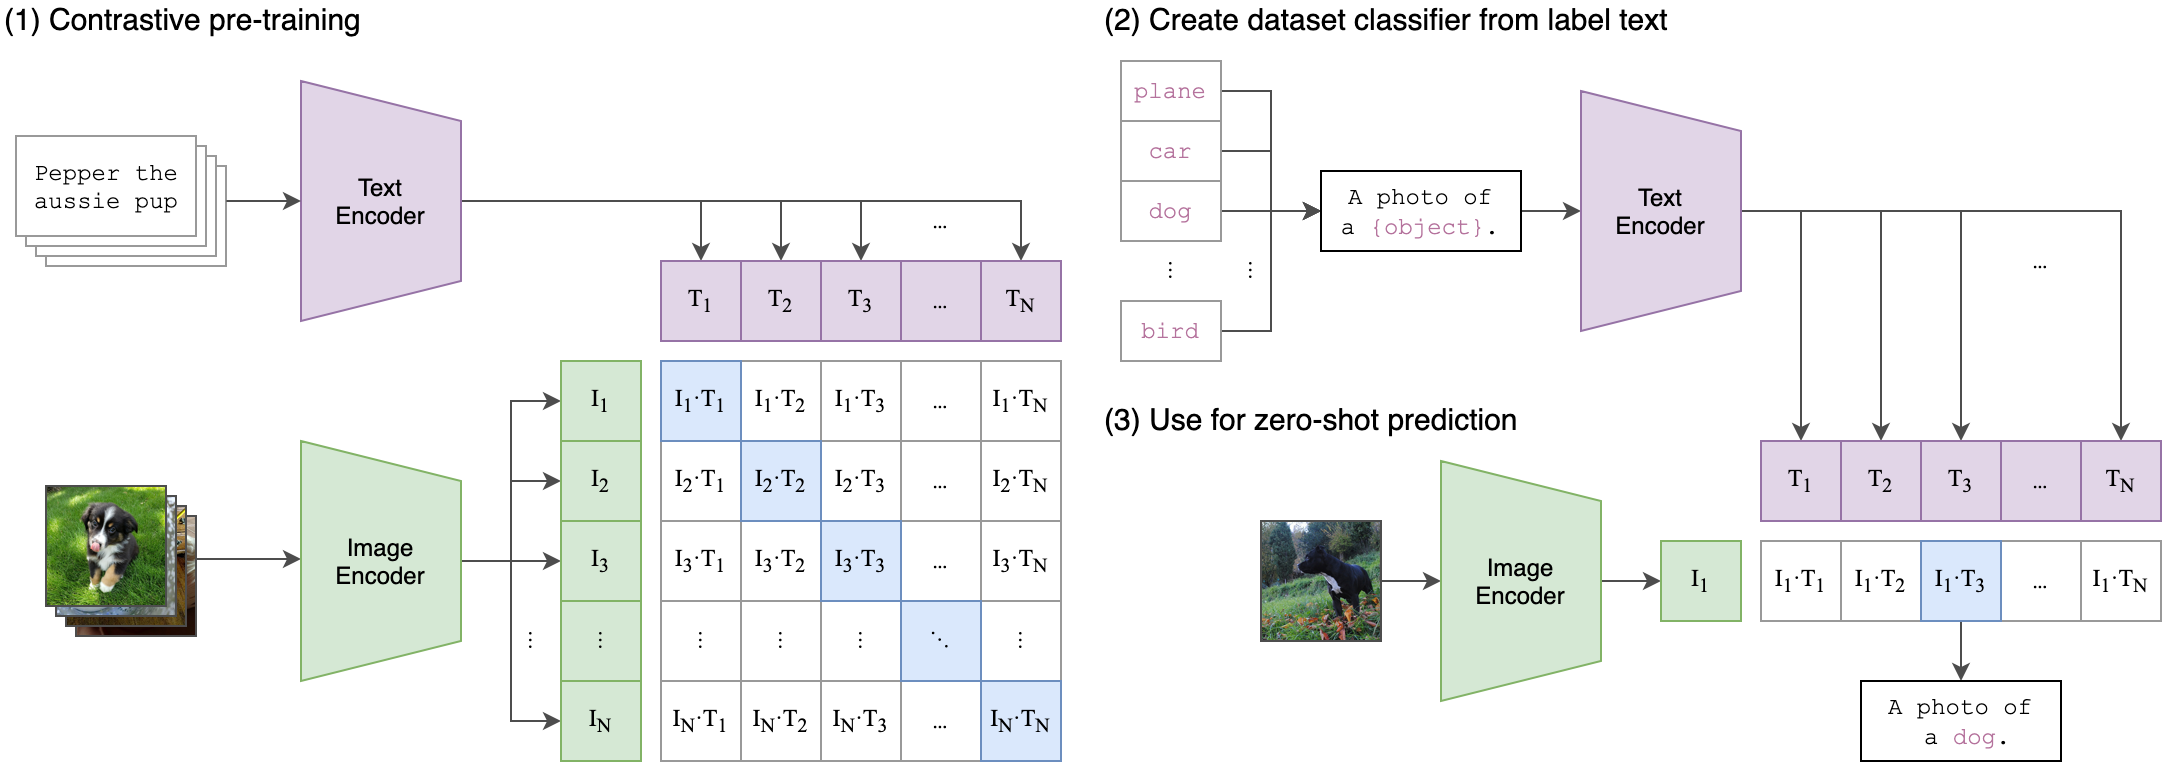


Although CLIP works with any image encoder (given that someone does the expensive pre-training), we will work with a vision transformer image encoder to demonstrate that our Jetson Nano can run modern models with a significant amount of parameters.

## Setup

First, we install some required packages.

In [1]:
######################################################
# TODO: Install the following packages               #
#                                                    #
######################################################

!pip3 install ftfy
!pip3 install regex
!pip3 install tqdm

######################################################
# END TODO                                           #
######################################################

    100% |################################| 71kB 3.2MB/s eta 0:00:01
  Running setup.py bdist_wheel for ftfy ... done
  Stored in directory: /root/.cache/pip/wheels/99/2c/e6/109c8a28fef7a443f67ba58df21fe1d0067ac3322e75e6b0b7
Successfully built ftfy
    100% |################################| 399kB 1.2MB/s eta 0:00:01
  Running setup.py bdist_wheel for regex ... done
  Stored in directory: /root/.cache/pip/wheels/a7/62/7b/4c52819d9bf94d52a6ce53911269b2be4d9c2f71f472b5b1d8
Successfully built regex
    100% |################################| 81kB 3.4MB/s eta 0:00:01


In [1]:
import clip
from clip import tokenize
import torch
from PIL import Image
from utils.clip_utils import tokenize_and_generate_features, clip_prediction
from utils.clip_inference import clip_webcam_inference

device = "cuda" if torch.cuda.is_available() else "cpu"

%load_ext autoreload
%autoreload 2

<font color="red"><strong>TODO:</strong></font> Run the following cell to load the CLIP model and the data preprocessor.

In [3]:
######################################################
# TODO: Load the CLIP model and data preprocessor    #
#                                                    #
#       This may take a little while.                #
######################################################

model, preprocess = clip.load("ViT-B/32", device=device)


######################################################
# END TODO                                           #
######################################################


######################################################
# OPTIONAL: MAKE SURE TO RESET YOUR KERNEL           #
#           BEFORE RUNNNING THIS.                    #
######################################################
# If you are curious, feel free to try out this model
# which is the a base ViT with different weights.
# ---------------uncomment---------------
# model, preprocess = clip.load("ViT-B/16", device=device)

# If you are really curious, feel free to run a
# larger model and see if you can push the limits of the
# Jetson Nano
# ---------------uncomment---------------
# model, preprocess = clip.load("ViT-L/14", device=device)
######################################################
# END OPTIONAL:                                      #
######################################################

## Zero-shot classification with CLIP

We will now perform zero-shot classification using CLIP.

We have provided a reference image and some classes you can use for developing your code.

First, we pre-compute the text features for a given classification task, so that we can re-use the text features with any input image.

<font color="red"><strong>TODO:</strong></font> Complete the methods **tokenize_and_generate_features** function in **utils/clip_utils.py**.

In [ ]:
###################################################
# TODO: Generate the text features using          #
#       tokenize_and_generate_features            #
#                                                 #
#       Use the reference classes to generate     #
#       the text features.                        #
###################################################

reference_classes = ['dog', 'cat', 'small lion', 'white cat', 'black cat', 'Pizza with pineapples and anchovies']

text_features = tokenize_and_generate_features(model, reference_classes, tokenize)

###################################################
# END TODO                                        #
###################################################

Secondly, we perform the classification following the description in the introduction.

<font color="red"><strong>TODO:</strong></font> Complete the methods **clip_prediction** function in **utils/clip_prediction.py**.

In [9]:
###################################################
# TODO: Perform prediction using  clip_prediction #
#                                                 #
#       Use the reference image,                  #
###################################################

reference_image = 'reference_cat.jpg'
ref_image = Image.open(reference_image)

class_probabilities, most_probable_class = clip_prediction(
    model, preprocess, ref_image, text_features
)

###################################################
# END TODO                                        #
###################################################

<font color="red"><strong>TODO:</strong></font> Run the following cell to evaluate your implementation. The class probabilities sum to 1, and the prediction should be a "White cat". The probability of "cat", "Small lion", and "Black cat" should also be higher than that of "Dog", which again is higher than that of "Pizza with pineapples and anchovies".

Sum of probabilities: 1.0
Predicted class: "White cat" 

Class Probabilities:
Dog: 0.0004
Cat: 0.0516
Small lion: 0.0281
White cat: 0.9155
Black cat: 0.0044
Pizza with pineapples and anchovies: 0.0

Reference Image:


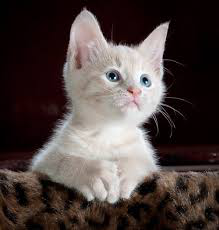

In [10]:
###################################################
# TODO: Inspect predictions.                      #
#                                                 #
###################################################

print(f'Sum of probabilities: {class_probabilities.sum()}')
print(f'Predicted class: "{reference_classes[most_probable_class].capitalize()}" \n')
print('Class Probabilities:')
for cls_name, cls_prob in zip(reference_classes, class_probabilities[0]):
    print(f'{cls_name.capitalize()}: {round(cls_prob.item(), 4)}')
print('\nReference Image:')
ref_image

###################################################
# END TODO                                        #
###################################################

## Define Tasks

As CLIP allows us to predict any definable object class, we need to define a set of classes that we want to predict for. 

<font color="red"><strong>TODO:</strong></font> Complete the three following tasks:
1. Define **three** different classification tasks you want to experiment with, all of which must use images captured with your webcam, and a set of classes that you want to predict for each of the three tasks. 
2. These three classification tasks should be different, and you must define:
    1. A tasks that you think CLIP will perform well on.
    2. A tasks that you think CLIP will struggle with or completely fails on.
    3. Any other tasks of choise, but include a list of at least 5 different classes.
3. **NOTE** Make sure that your results later in the notebook reflect the requirements of these three tasks. You may re-define your problems later if you find that A. is too hard, or B. is too easy for CLIP to predict.

In [4]:
###################################################
# TODO: Define the names of classes that will be  #
#       predicted and a name for the three        #
#       different classification task.            #
#                                                 #
#       Replace the following list elements       #
#       with your classes.                        #
###################################################

# Problem 2.A - Easy Classification Task
easy_class_names =  ['open hand', 'fist', 'pointing finger']

# Problem 2.B - Hard Classification Task
hard_class_names = ['left hand', 'right hand', 'a finger']

# Problem 2.C - At least 5 classes
custom_class_names =  [ 'open hand', 'fist','two fingers','three fingers', 'thumbs up']

###################################################
# END TODO                                        #
###################################################

Now, we will use the implemented code to perform classification for each of the defined classes.

### <font color="red"><strong>[NOTE]</strong></font> If you run out of GPU memory or other unforseen CUDA errors, restart your kernel and re-load the model before proceeding with the following tasks. You might have to do this for each task.

## Problem 2.A - Easy Classification Task

Run the following code to perform classification of your easy problem

In [7]:
###################################################
# TODO: Generate the text features using          #
#       tokenize_and_generate_features            #
#                                                 #
#       Use the easy_class_names to generate      #
#       the text features.                        #
#                                                 #
#       Then perform webcam inference using       #
#       clip_webcam_inference.                    #
###################################################

# Generate text features: 
easy_class_text_features = tokenize_and_generate_features(model, easy_class_names, tokenize)
# Webcam inference:
clip_webcam_inference(model, preprocess, easy_class_text_features, easy_class_names)

###################################################
# END TODO                                        #
###################################################

Video feed stopped by user.


## Insert a screenshot of your easy problem inference below.

<font color="red"><strong>TODO:</strong></font> 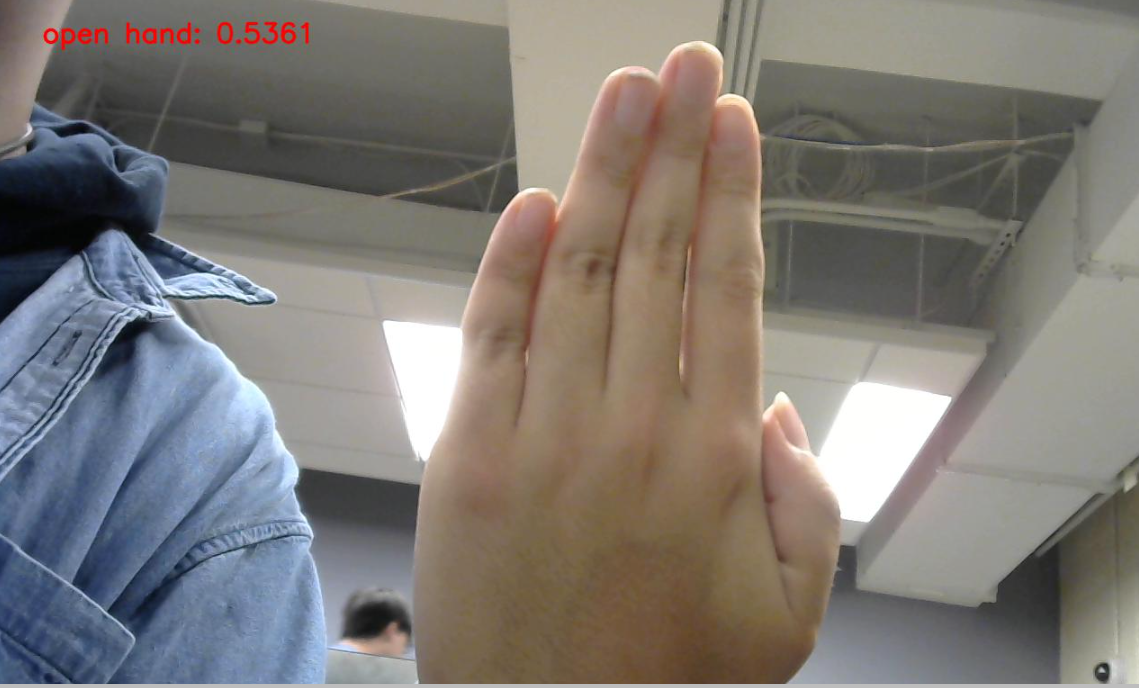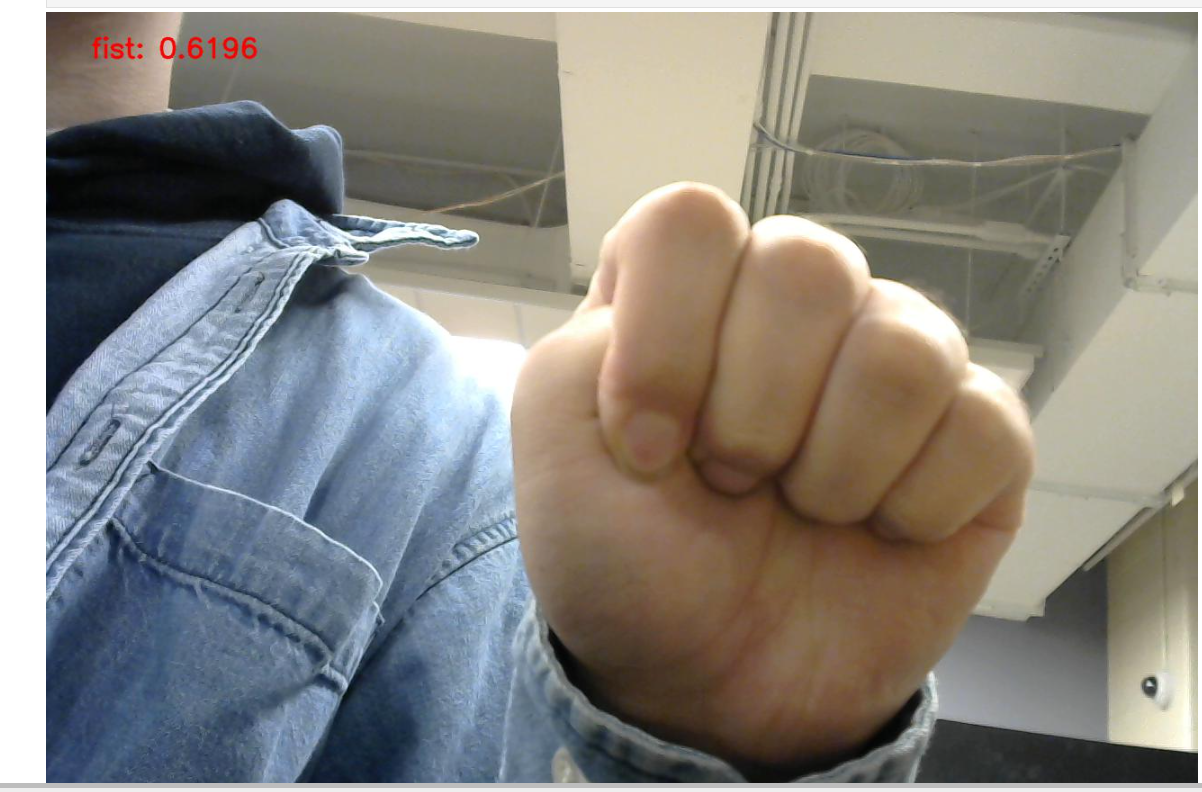
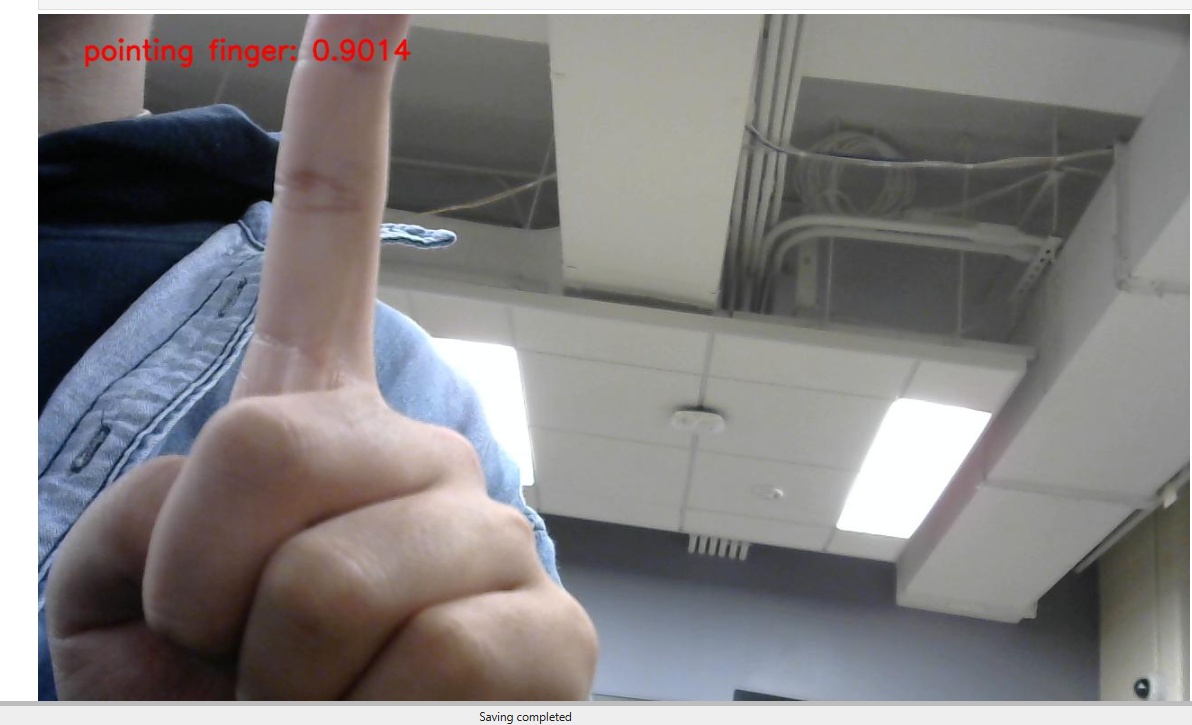

## Comment on your models performance.

Is the classification accurate?
* <font color="red"><strong>TODO:</strong></font> For grasping the fist and pointing with the finger, the recognition is relatively accurate. However, the fist sometimes gets mistaken for pointing with the finger. Opening one's hands is very difficult to be recognized. It is almost always mistaken for pointing with the finger.

What makes this classification task easy?
* <font color="red"><strong>TODO:</strong></font> The categories are highly distinguishable visually. The contours and structures of opening hands, clenching fists, and pointing with a single finger are very different. Moreover, the identified objects are always "hands", the backgrounds are basically the same, but the gestures are very clear, making classification much easier.

Why do you think CLIP performs well on this task?
* <font color="red"><strong>TODO:</strong></font> Considering the poor performance on recognizing "open hand", the performance is just so so.


## Problem 2.B - Hard Classification Task

Run the following code to perform classification of your hard problem

In [5]:
###################################################
# TODO: Generate the text features using          #
#       tokenize_and_generate_features            #
#                                                 #
#       Use the hard_class_names to generate      #
#       the text features.                        #
#                                                 #
#       Then perform webcam inference using       #
#       clip_webcam_inference.                    #
###################################################

# Generate text features: 
hard_class_text_features = tokenize_and_generate_features(model, hard_class_names, tokenize)
# Webcam inference:
clip_webcam_inference(model, preprocess, hard_class_text_features, hard_class_names)

###################################################
# END TODO                                        #
###################################################

Video feed stopped by user.


## Insert a screenshot of your hard problem inference below.

<font color="red"><strong>TODO:</strong></font> Insert screenshot here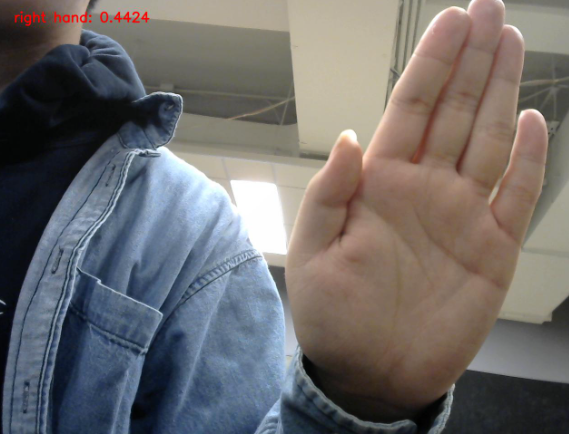
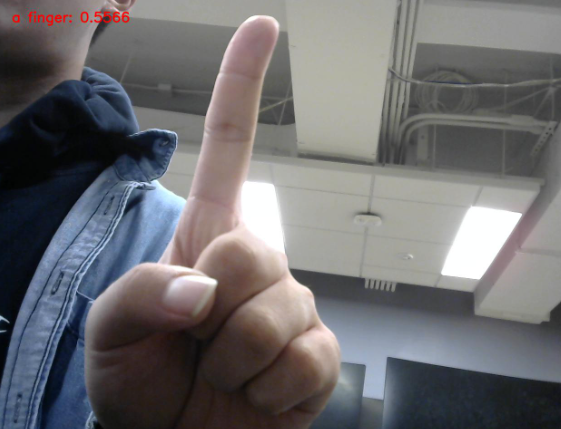
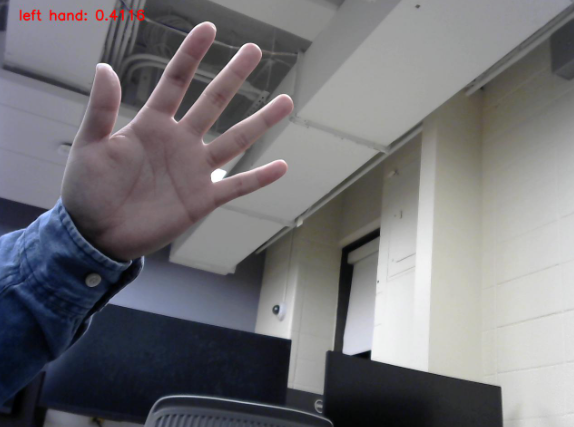

## Comment on your models performance on the hard problem.

Is the classification accurate?
* <font color="red"><strong>TODO:</strong></font> The classification accuracy of the model has significantly declined on difficult tasks. It can sometimes predict correctly, but the stability of its predictions is far inferior to that of simple tasks. Especially when distinguishing between the left hand and the right hand, or when the distance between the hand and the camera changes, the model can easily confuse the categories.


What makes this classification task hard?
* <font color="red"><strong>TODO:</strong></font> All categories are visually very similar. Essentially, they are all objects like "hands", with the only differences lying in fine-grained attributes such as orientation, left and right directions, and distance from the camera, rather than the object categories themselves.

Are there any characteristics that makes this classification task hard?
* <font color="red"><strong>TODO:</strong></font> The main difficulties come from subtle visual differences, perspective sensitivity, and the ambiguity of the text prompts themselves. Lighting, shooting Angle, hand rotation, and the specific position of the hand in the frame will all affect the model's prediction. In addition, from the perspective of some cameras, the left hand and the right hand may appear very similar visually, making them more prone to confusion.

Although CLIP is a very impressive model, it still has many failure modes. Do you see any failures for your classification task?
* <font color="red"><strong>TODO:</strong></font>Yes. An obvious failure mode is the unstable prediction between consecutive frames. Another one is semantic confusion between similar prompt words, especially when the hand is partially covered, too close to the camera, or not in the center of the frame. This indicates that CLIP is strong in generalized semantic recognition, but relatively weak in fine-grained state discrimination.


## Problem 2.C - Custom Classification Task

Run the following code to perform classification of your custom problem

In [ ]:
###################################################
# TODO: Generate the text features using          #
#       tokenize_and_generate_features            #
#                                                 #
#       Use the custom_class_names to generate    #
#       the text features.                        #
#                                                 #
#       Then perform webcam inference using       #
#       clip_webcam_inference.                    #
###################################################

# Generate text features: 
custom_class_text_features = tokenize_and_generate_features(model, custom_class_names, tokenize)
# Webcam inference:
clip_webcam_inference(model, preprocess, custom_class_text_features, custom_class_names)

###################################################
# END TODO                                        #
###################################################

## Insert a screenshot of your custom problem inference below.

<font color="red"><strong>TODO:</strong></font> Insert screenshot here


## Comment on your models performance on the custom problem.

Is the classification accurate?
* <font color="red"><strong>TODO:</strong></font> Moderately accurate. It is usually capable of recognizing gestures such as opening hands, making fists, and giving likes, which are quite different. However, for categories that are closer together like "two fingers" and "three fingers", if the posture is not clear enough, the prediction will be less stable. 

Does adding more classes to your problem affect the classification performance?
* <font color="red"><strong>TODO:</strong></font> Yes. Increasing the number of categories usually makes the classification problem more difficult because the model needs to make choices among more text cues, and some of these categories may be semantically or visually similar to each other. As the number of categories increases, it becomes easier for related categories to be confused, and the confidence level of the highest probability prediction may also decrease. This leads to an increase in the rate of incorrect judgments.

## Discussion

### Question 1: Discuss the inference performance of the CLIP model in terms of run-time. 

* Does it run fast it enough for the feed to be real time? 
* Is this surprising considering the image and text encoders we're using?
* How does this compare to the previous models we have ran in class?

<font color="red"><strong>TODO:</strong></font> The inference speed of the CLIP model is relatively fast and it can continuously process the input from the camera. However, compared to lightweight models, there is still a slight delay. Overall, its performance can be described as... 
I find this quite astonishing. The structure of CLIP is rather complex. It incorporates both an image encoder and a text encoder. However, we use ViT as the image encoder, and its computational cost is much higher than that of CNN. 
Compared with the models used in previous courses (such as small CNN classifiers or YOLO detection models), the inference speed of CLIP is slower. However, the advantage of CLIP lies in its zero-shot capability, which enables it to recognize any category without the need for re-training. This flexibility compensates for the speed disadvantage. This left a very deep impression on me.

### Question 2: Think back to the previous labs in this class.

* Are there any techniques that you have previously seen that might help in improving the inference speed of CLIP?
* Are there any potential concerns with applying these techniques to CLIP?

<font color="red"><strong>TODO:</strong></font> I have learned that TorchScript, TensorRT, and low-precision inference (such as FP16) can be applied to CLIP. Batching and the pre-computed text features used in this experiment can also be utilized. 
However, applying these optimization methods to CLIP also has some potential issues. Since the core of CLIP is the comparison of image and text embeddings, low-precision calculations may affect numerical stability, thereby altering the category sorting results. Additionally, the Transformer architecture is more difficult to optimize efficiently compared to CNN, and some acceleration tools do not provide adequate support for it. At the same time, aggressive optimizations (such as quantization) may lead to a decrease in accuracy.

### Question 3: Consider your own project for this class. 

* Do you think CLIP would be useful in any way for your own project?

<font color="red"><strong>TODO:</strong></font> My project is about pavement damage detection, which is a fine-grained classification problem. Different types of pavement damages (such as cracks, potholes, wear and tear, etc.) often have relatively small visual differences, and precise positioning and detailed feature extraction are required. However, CLIP was not specifically designed for this kind of fine-grained structural damage classification task. 
However, CLIP can still serve as a high-level semantic tool. For instance, it can be used to distinguish between "normal road surfaces" and "damaged road surfaces" in coarse-grained categories, or it can be employed at the early stage of a project for data filtering and rapid annotation. 

I'm considering using it for the data preprocessing part of another course project.